In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# ОБЩАЯ АНАЛИТИКА

## 1. KPI (ОБЩАЯ АНАЛИТИКА)
- Выручка общая
- Количество клиентов
- Количество заказов
- Средний чек
- Отток (одноразовые покупки)



In [15]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 1. ЗАГРУЗКА ДАННЫХ
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

df = pd.read_csv('../data/processed/cleaned_retail.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Данные загружены: {len(df):,} строк, {len(df.columns)} колонок")
print(f"Период: {df['InvoiceDate'].min()} — {df['InvoiceDate'].max()}")

Данные загружены: 779,425 строк, 20 колонок
Период: 2009-12-01 07:45:00 — 2011-12-09 12:50:00


In [16]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 2. KPI — КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ (включая отток)
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :

total_revenue = df['Revenue'].sum()
total_customers = df['Customer ID'].nunique()
total_orders = df['Invoice'].nunique()
avg_order_value = total_revenue / total_orders

# Отток — клиенты с 1 покупкой
customer_orders = df.groupby('Customer ID')['Invoice'].nunique()
one_time_customers = (customer_orders == 1).sum()
churn_rate = (one_time_customers / total_customers) * 100

print("\n" + "="*60)
print("KPI — КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ")
print("="*60)

print(f"Total Revenue:     £{total_revenue/1e6:.2f} млн")
print(f"Total Customers:   {total_customers:,}")
print(f"Total Orders:      {total_orders:,}")
print(f"Avg Order Value:   £{avg_order_value:.2f}")
print(f"Churn Rate (1 purchase): {churn_rate:.1f}% ({one_time_customers:,} customers)")


KPI — КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ
Total Revenue:     £17.37 млн
Total Customers:   5,878
Total Orders:      36,969
Avg Order Value:   £469.98
Churn Rate (1 purchase): 27.6% (1,623 customers)


## 2. ДИНАМИКА
- Выручка по месяцам (график)
- MoM (Month over Month) в %
- Скользящие средние (MA3, MA6)



************************************************************
ДИНАМИКА ВЫРУЧКИ ПО МЕСЯЦАМ
************************************************************


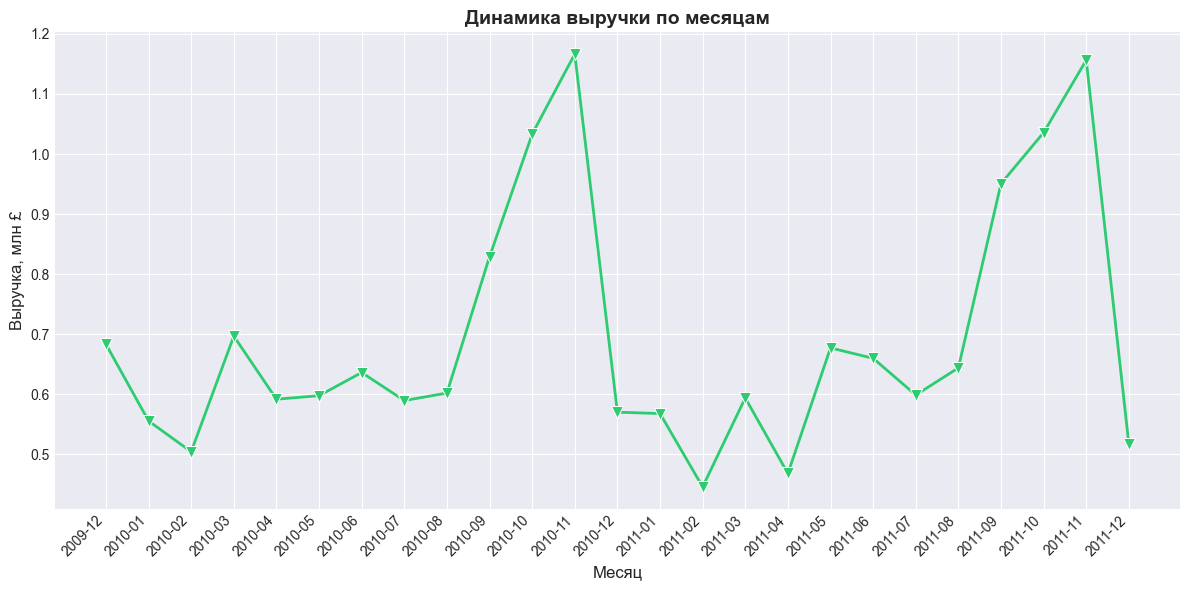

,YearMonth,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002
5,2010-05,597833.380
6,2010-06,636371.130
7,2010-07,589736.170
8,2010-08,602224.600
9,2010-09,829013.951


In [17]:
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :
# 2. ДИНАМИКА (SEABORN)
# : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : : :


# Выручка по месяцам (график)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
# df['YearMonth'].value_counts()
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth_str'] = monthly_revenue['YearMonth'].astype(str)
monthly_revenue['Revenue_m'] = monthly_revenue['Revenue'] /1_000_000

print('*'*60)
print('ДИНАМИКА ВЫРУЧКИ ПО МЕСЯЦАМ')
print('*'*60)
# print(monthly_revenue[['YearMonth_str', 'Revenue_m']].to_string(index=False))

# График выручки по месяцам
plt.Figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x='YearMonth_str',
    y='Revenue_m',
    marker='v',
    linewidth=2,
    markersize=8,
    color='#2ecc71'
)

plt.title('Динамика выручки по месяцам', fontsize=14, fontweight = 'bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка, млн £', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()

monthly_revenue[['YearMonth', 'Revenue']]
# print(monthly_revenue[['YearMonth', 'Revenue']].to_string( index=False))

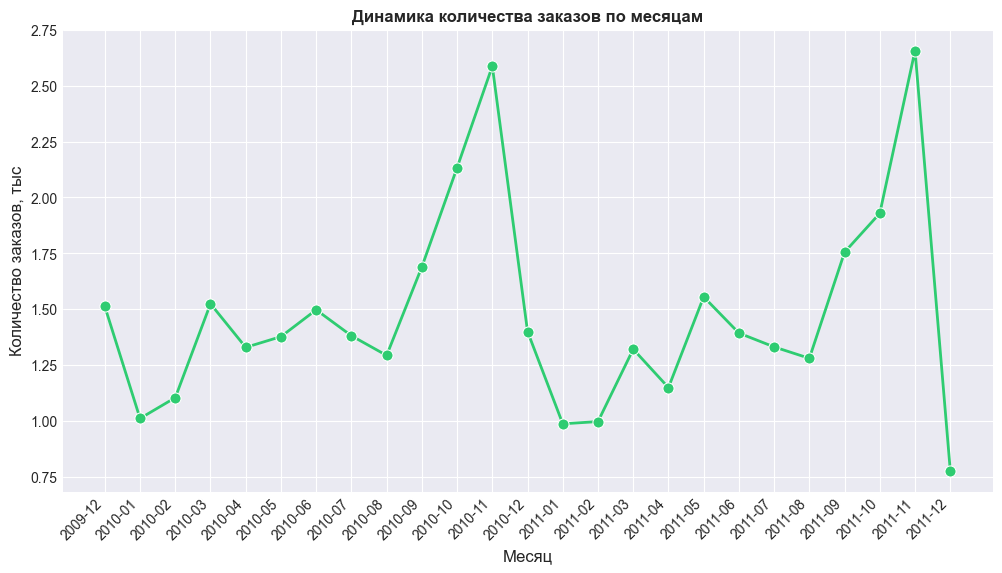

,YearMonth,Invoice,Invoice_t
0,2009-12,1512,1.512
1,2010-01,1011,1.011
2,2010-02,1104,1.104
3,2010-03,1524,1.524
4,2010-04,1329,1.329
5,2010-05,1377,1.377
6,2010-06,1497,1.497
7,2010-07,1381,1.381
8,2010-08,1293,1.293
9,2010-09,1689,1.689


In [18]:
# Количество заказов по месяцам

monthly_orders = df.groupby('YearMonth')['Invoice'].nunique().reset_index()
monthly_orders['YearMonth_str'] = monthly_orders['YearMonth'].astype(str)
monthly_orders['Invoice_t'] = monthly_orders['Invoice'] / 1000


plt.Figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_orders,
    x='YearMonth_str',
    y='Invoice_t',
    marker='o',
    linewidth=2,
    markersize=8,
    color='#2ecc71'
)
plt.title('Динамика количества заказов по месяцам', fontsize=12, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Количество заказов, тыс', fontsize=12)
plt.show()
monthly_orders[['YearMonth', 'Invoice','Invoice_t']]

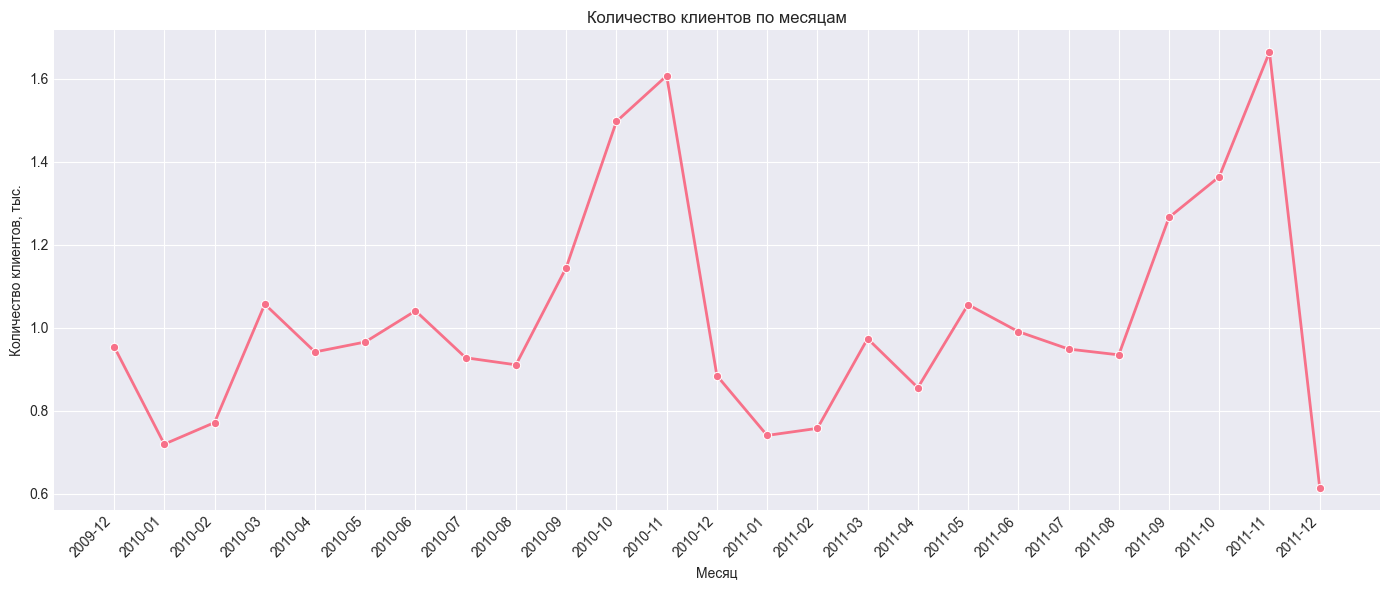

,YearMonth,Customers_cnt_th
0,2009-12,0.955
1,2010-01,0.720
2,2010-02,0.772
3,2010-03,1.057
4,2010-04,0.942
5,2010-05,0.966
6,2010-06,1.041
7,2010-07,0.928
8,2010-08,0.911
9,2010-09,1.145


In [20]:
# Количество клиентов по месяцам
monthly_customers = df.groupby('YearMonth')['Customer ID'].nunique().reset_index()
monthly_customers['Customers_cnt_th'] = monthly_customers['Customer ID'] / 1000
monthly_customers['YearMonth_str'] = monthly_customers['YearMonth'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly_customers,
    x='YearMonth_str',
    y='Customers_cnt_th',
    linewidth=2,
    marker='o'
)

plt.xticks(rotation=45, ha='right')
plt.title('Количество клиентов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество клиентов, тыс.')
plt.tight_layout()

plt.show()


monthly_customers[['YearMonth', 'Customers_cnt_th']]


## 3. ГЕОАНАЛИТИКА
- Топ-10 стран по выручке
- Доля Великобритании
- Выручка по странам (горизонтальные бары)



## 4. ABC АНАЛИЗ (ПАРЕТО)
- Классификация товаров A (80%), B (15%), C (5%)
- График Парето (столбцы + кумулятивная линия)